<h1> Pipeline RAG </h1>
Objetivo: Crie um pipeline de RAG incluindo extração de documentos, vetorização (ChoromaDB), recuperação de documentos (RAG - Similariedade do Cosseno) para posteriormente incluir na LLM. </br>
Entrada: documentos para vetorização </br>
Saída: banco vetorizado (ChromaDB), módulo RAG pronto. </br>

<h3> Importação de pacotes e bibliotecas </h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
import tiktoken
import spacy
import numpy as np
from scipy.stats import norm

import chromadb
from sentence_transformers import SentenceTransformer

c:\Users\roger\.conda\envs\itau\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download do vocabulário em português

In [10]:
!python -m spacy download pt_core_news_sm

  Using cached pt_core_news_sm-3.8.0-py3-none-any.whl (13.0 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


<h3> Definição de Métodos e Funções </h3>

In [12]:
# Modelo de português
nlp = spacy.load("pt_core_news_sm")

# Tokenizador para estimativa de tokens
encoding = tiktoken.get_encoding("cl100k_base")

In [37]:
def gerar_histograma(
    dados,
    titulo,
    xlabel,
    ylabel,
    bins_qtde=10
):
    # Remover valores nulos
    dados = dados.dropna()

    # Média e desvio padrão
    media = dados.mean()
    desvio_padrao = dados.std()

    # Paleta de cores
    colors = plt.cm.Blues(
        np.linspace(0.3, 0.8, bins_qtde)
    )

    # Criando a figura
    plt.figure(figsize=(8, 6))

    # Histograma
    n, bins, patches = plt.hist(
        dados,
        bins=bins_qtde,
        edgecolor="black",
        density=True
    )

    # Aplicando cores às barras
    for i, patch in enumerate(patches):
        patch.set_facecolor(colors[i])

    # -----------------------------
    # Curva de distribuição normal
    # -----------------------------

    x = np.linspace(
        dados.min(),
        dados.max(),
        1000
    )

    curva_normal = norm.pdf(
        x,
        media,
        desvio_padrao
    )

    plt.plot(
        x,
        curva_normal,
        linewidth=2,
        label=f"Distribuição Normal\nMédia = {media:,.0f}"
    )

    # Título e rótulos
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Legenda
    plt.legend()

    # Remover notação científica
    plt.ticklabel_format(
        style="plain",
        axis="x",
        useOffset=False
    )

    plt.tight_layout()
    plt.show()

In [27]:
def gerar_grafico_tokens(df_metricas, coluna_documento='nome_arquivo'):

    plt.figure(figsize=(12, 6))

    # Paleta de azuis
    cores = plt.cm.Blues(
        np.linspace(0.45, 0.90, len(df_metricas))
    )

    barras = plt.barh(
        df_metricas[coluna_documento],
        df_metricas['qtd_tokens'],
        color=cores
    )

    # Valores ao final das barras
    for barra, valor in zip(
        barras,
        df_metricas['qtd_tokens']
    ):

        valor_formatado = (
            f'{valor:,.0f}'
            .replace(',', 'X')
            .replace('.', ',')
            .replace('X', '.')
        )

        plt.text(
            barra.get_width(),
            barra.get_y() + barra.get_height() / 2,
            f' {valor_formatado}',
            ha='left',
            va='center',
            fontsize=9
        )

    plt.title('Quantidade de Tokens por Documento')
    plt.xlabel('Quantidade de Tokens')
    plt.ylabel('Documento')

    plt.tight_layout()
    plt.show()

In [33]:
def gerar_grafico_palavras(
    df_metricas,
    coluna_documento='nome_arquivo'
):

    plt.figure(figsize=(12, 6))

    # Paleta de azuis
    cores = plt.cm.Blues(
        np.linspace(0.45, 0.90, len(df_metricas))
    )

    barras = plt.barh(
        df_metricas[coluna_documento],
        df_metricas['qtd_palavras'],
        color=cores
    )

    # Valores ao final das barras
    for barra, valor in zip(
        barras,
        df_metricas['qtd_palavras']
    ):

        valor_formatado = (
            f'{valor:,.0f}'
            .replace(',', 'X')
            .replace('.', ',')
            .replace('X', '.')
        )

        plt.text(
            barra.get_width(),
            barra.get_y() + barra.get_height() / 2,
            f' {valor_formatado}',
            ha='left',
            va='center',
            fontsize=9
        )

    plt.title('Quantidade de Palavras por Documento')
    plt.xlabel('Quantidade de Palavras')
    plt.ylabel('Documento')

    plt.tight_layout()
    plt.show()

In [15]:
def gerar_estatistica_breve(dataframe, coluna_texto='txt'):

    df = dataframe.copy()

    # =========================================================
    # Processamento dos textos
    # =========================================================

    def analisar_texto(texto):

        if not isinstance(texto, str) or not texto.strip():
            return 0, 0, 0

        doc = nlp(texto)

        # Palavras: exclui pontuação e espaços
        palavras = [
            token
            for token in doc
            if not token.is_space and not token.is_punct
        ]

        qtd_palavras = len(palavras)

        # Frases
        qtd_frases = len(list(doc.sents))

        # Tokens
        qtd_tokens = len(encoding.encode(texto))

        return qtd_palavras, qtd_frases, qtd_tokens

    # =========================================================
    # Aplicar análise
    # =========================================================

    resultados = df[coluna_texto].apply(analisar_texto)

    df['qtd_palavras'] = resultados.apply(lambda x: x[0])
    df['qtd_frases'] = resultados.apply(lambda x: x[1])
    df['qtd_tokens'] = resultados.apply(lambda x: x[2])

    # =========================================================
    # Estatísticas gerais
    # =========================================================

    quantidade_registros = len(df)

    palavras_total = df['qtd_palavras'].sum()
    frases_total = df['qtd_frases'].sum()
    tokens_total = df['qtd_tokens'].sum()

    media_palavras = df['qtd_palavras'].mean()
    media_frases = df['qtd_frases'].mean()
    media_tokens = df['qtd_tokens'].mean()

    # =========================================================
    # Exibição
    # =========================================================

    print("=" * 60)
    print("ESTATÍSTICAS DOS DOCUMENTOS")
    print("=" * 60)

    print(f"Quantidade de registros:      {quantidade_registros:,}")
    print(f"Palavras totais:              {palavras_total:,}")
    print(f"Média de palavras:            {media_palavras:,.2f}")
    print(f"Frases totais:                {frases_total:,}")
    print(f"Média de frases:              {media_frases:,.2f}")
    print(f"Tokens totais:                {tokens_total:,}")
    print(f"Média de tokens:              {media_tokens:,.2f}")

    print("=" * 60)

    # =========================================================
    # DataFrame específico para gráficos
    # =========================================================

    # Se existir uma coluna identificadora do documento,
    # ela será utilizada. Caso contrário, usa o índice.
    if 'nome_arquivo' in df.columns:
        identificador = 'nome_arquivo'
    elif 'id_documento' in df.columns:
        identificador = 'id_documento'
    else:
        df['id_documento'] = df.index.astype(str)
        identificador = 'id_documento'

    df_metricas = df[
        [
            identificador,
            'qtd_palavras',
            'qtd_frases',
            'qtd_tokens'
        ]
    ].copy()

    return df, df_metricas

In [2]:
def carregar_txts(pasta):
    try:
        pasta = Path(pasta)

        documentos = []

        for arquivo in pasta.glob("*.txt"):
            with open(arquivo, "r", encoding="utf-8") as f:
                texto = f.read()

            documentos.append({
                "nome_arquivo": arquivo.name,
                "texto": texto
            })

        return pd.DataFrame(documentos)
    except Exception as excecao:
        print(f"Ouve um erro ao carregar e processar os arquivos para RAG {excecao}")
    else:
        print(f"Processo de extração de textos nos documentos concluído")

In [ ]:
# ============================================================
# 1. MODELO DE EMBEDDINGS
# ============================================================

def carregar_modelo_embedding(
    nome_modelo='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
):
    
    modelo = SentenceTransformer(
        nome_modelo
    )

    return modelo


# ============================================================
# 2. CRIAR E POPULAR CHROMADB
# ============================================================

def criar_chromadb(
    df,
    modelo_embedding,
    nome_colecao='documentos',
    caminho_db='../chroma_db'
):

    cliente_chroma = chromadb.PersistentClient(
        path=caminho_db
    )

    colecao = cliente_chroma.get_or_create_collection(
        name=nome_colecao
    )

    documentos = (
        df['texto']
        .fillna('')
        .astype(str)
        .tolist()
    )

    ids = (
        df['id']
        .astype(str)
        .tolist()
    )

    embeddings = modelo_embedding.encode(
        documentos,
        show_progress_bar=True
    )

    colecao.add(
        ids=ids,
        documents=documentos,
        embeddings=embeddings.tolist()
    )

    print(
        f'{len(documentos)} documentos adicionados '
        f'à coleção "{nome_colecao}".'
    )

    return colecao


# ============================================================
# 3. SIMILARIDADE DE COSSENO
# ============================================================

def similaridade_cosseno(
    vetor_a,
    vetor_b
):
    """
    Calcula a similaridade de cosseno entre
    dois vetores.
    """

    vetor_a = np.array(vetor_a)
    vetor_b = np.array(vetor_b)

    norma_a = np.linalg.norm(vetor_a)
    norma_b = np.linalg.norm(vetor_b)

    if norma_a == 0 or norma_b == 0:
        return 0.0

    return np.dot(
        vetor_a,
        vetor_b
    ) / (
        norma_a * norma_b
    )


# ============================================================
# 4. BUSCA SEMÂNTICA
# ============================================================

def buscar_documentos(
    consulta,
    modelo_embedding,
    colecao,
    n_resultados=5
):
    """
    Busca documentos semanticamente similares.

    Retorna:
        id_documento
        texto
        similaridade_cosseno
        score_similaridade (0-100)
    """

    # --------------------------------------------------------
    # Embedding da consulta
    # --------------------------------------------------------

    embedding_consulta = modelo_embedding.encode(
        consulta
    )


    # --------------------------------------------------------
    # Buscar documentos no Chroma
    # --------------------------------------------------------

    resultado = colecao.query(
        query_embeddings=[
            embedding_consulta.tolist()
        ],
        n_results=n_resultados,
        include=[
            'documents',
            'embeddings'
        ]
    )


    resultados = []


    # --------------------------------------------------------
    # Calcular similaridade
    # --------------------------------------------------------

    for i in range(
        len(resultado['ids'][0])
    ):

        id_documento = resultado[
            'ids'
        ][0][i]

        documento = resultado[
            'documents'
        ][0][i]

        embedding_documento = resultado[
            'embeddings'
        ][0][i]


        # Similaridade de cosseno
        similaridade = similaridade_cosseno(
            embedding_consulta,
            embedding_documento
        )


        # ----------------------------------------------------
        # Converter para escala 0-100
        # ----------------------------------------------------
        
        # Cosseno normalmente varia entre -1 e 1.
        # Transformação para 0-100:
        
        score = (
            (similaridade + 1) / 2
        ) * 100


        resultados.append({
            'id_documento': id_documento,
            'texto': documento,
            'similaridade_cosseno': similaridade,
            'score_similaridade': score
        })


    return resultados

<h3> Definição do Escopo Principal(Main) </h3>

<h4> 1. Preparando os documentos para a vetorização. Extração de textos dos documentos. </h4>

In [3]:
%%time
# Carregando os arquivos e extraindo os textos
df_documentos_rag = carregar_txts("../documentos_rag")

CPU times: total: 0 ns
Wall time: 349 ms


In [6]:
#df_documentos_rag
df_documentos_rag.to_csv(
    "df_documentos_rag.csv",
    index=False,
    encoding="utf-8-sig"
)

<h4> Estatística Breve </h4>

In [58]:
df_documentos, df_metricas = gerar_estatistica_breve(
    df_documentos_rag,
    coluna_texto='texto'
)

ESTATÍSTICAS DOS DOCUMENTOS
Quantidade de registros:      5
Palavras totais:              1,974
Média de palavras:            394.80
Frases totais:                192
Média de frases:              38.40
Tokens totais:                3,998
Média de tokens:              799.60


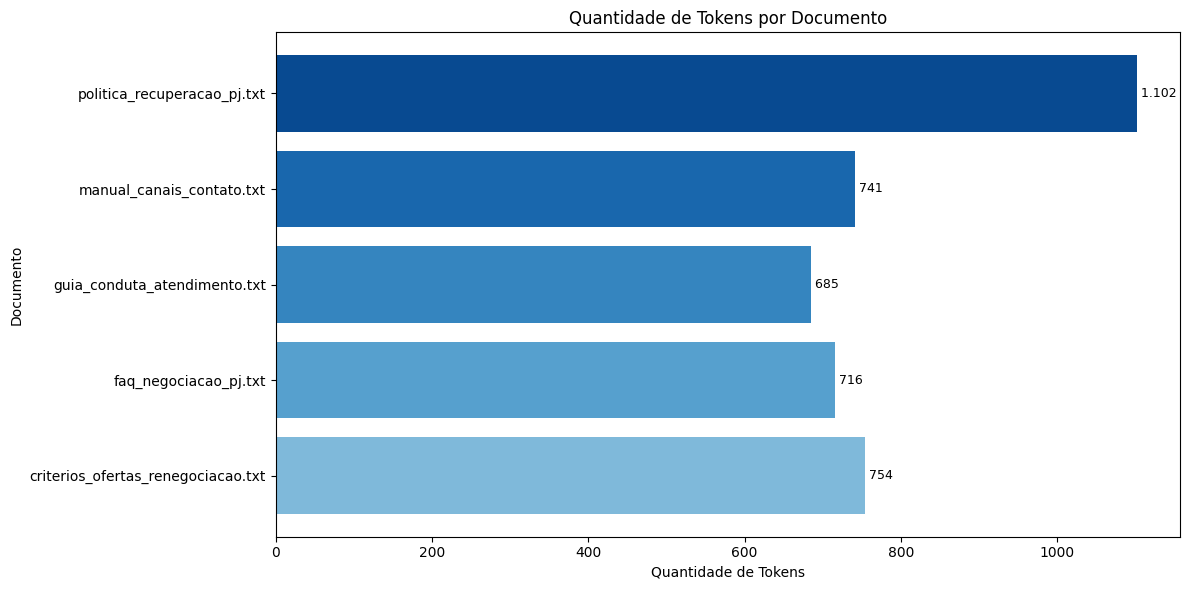

In [59]:
gerar_grafico_tokens(df_metricas)

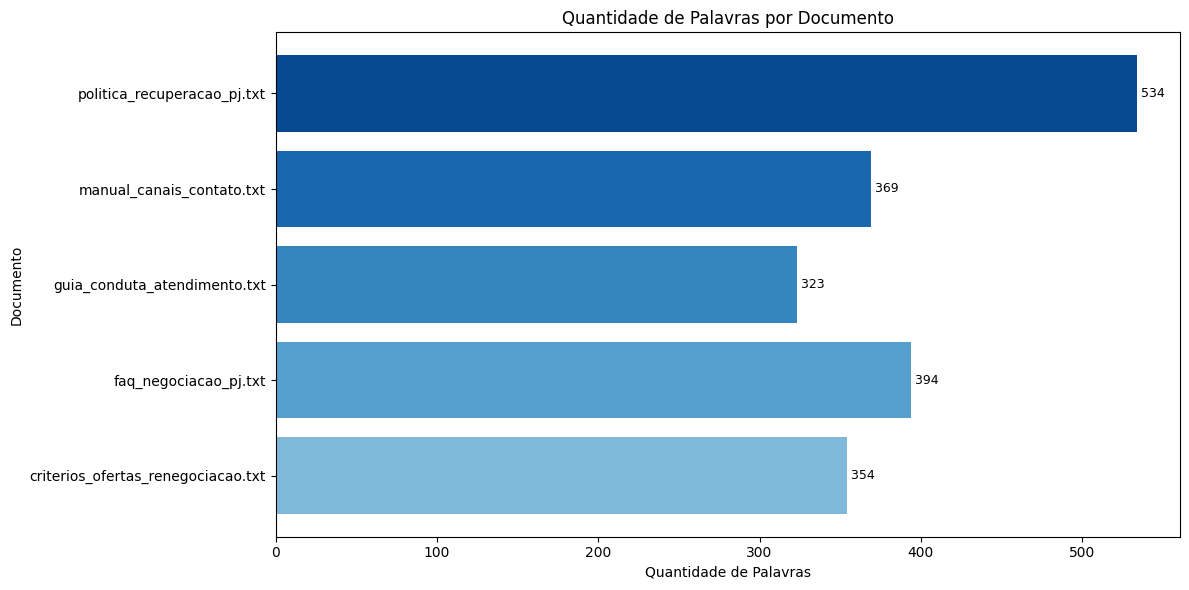

In [60]:
gerar_grafico_palavras(df_metricas)

In [61]:
df_metricas['qtd_tokens'].describe()

count       5.000000
mean      799.600000
std       171.085651
min       685.000000
25%       716.000000
50%       741.000000
75%       754.000000
max      1102.000000
Name: qtd_tokens, dtype: float64

In [62]:
df_metricas['qtd_palavras'].describe()

count      5.000000
mean     394.800000
std       81.949375
min      323.000000
25%      354.000000
50%      369.000000
75%      394.000000
max      534.000000
Name: qtd_palavras, dtype: float64

Quantidade de tókens em média é: 799. Varia entre 685(documento mais curto) - 1102(documento mais longo).
Quantidade de palavras em média é: 394. Varia entre 323(documento mais curto) - 534(documento mais longo).


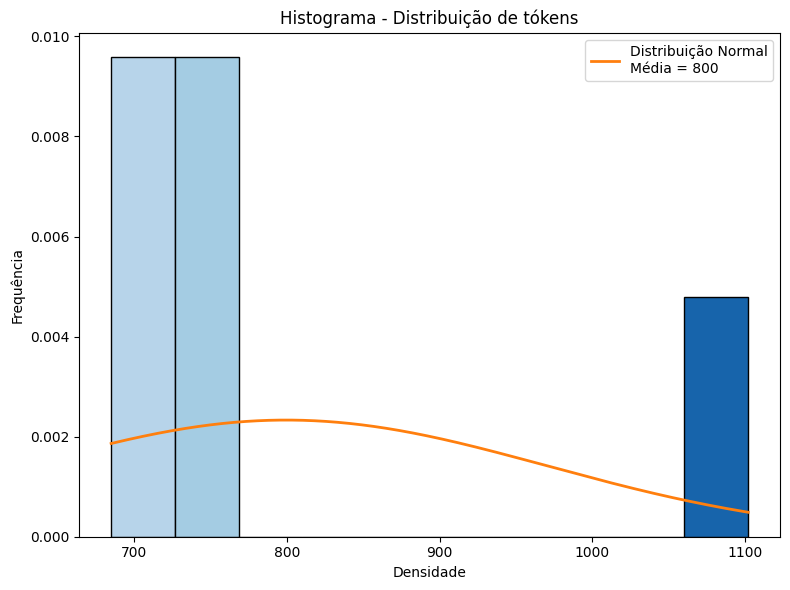

In [63]:
gerar_histograma(df_metricas['qtd_tokens'],"Histograma - Distribuição de tókens","Densidade","Frequência",10)

In [64]:
df_metricas

,nome_arquivo,qtd_palavras,qtd_frases,qtd_tokens
0,criterios_ofertas_renegociacao.txt,354,35,754
1,faq_negociacao_pj.txt,394,44,716
2,guia_conduta_atendimento.txt,323,26,685
3,manual_canais_contato.txt,369,38,741
4,politica_recuperacao_pj.txt,534,49,1102


In [65]:
# Salvando o dataframe com as métricas
try:
    df_metricas.to_csv(
        "../metricas_rag/metricas_estatistica_palavras.csv",
        index=False,
        encoding="utf-8-sig"
    )
except Exception as excecao:
    print(f"Ouve um erro ao salvar o arquivo {excecao}")
else:
    print(f"Arquivo salvo com sucesso.")

Arquivo salvo com sucesso.


In [66]:
df_documentos['id'] = range(1, len(df_documentos) + 1)
df_documentos = df_documentos[['id','nome_arquivo','texto']]
df_documentos.sample(3)

,id,nome_arquivo,texto
2,3,guia_conduta_atendimento.txt,GUIA DE CONDUTA NO ATENDIMENTO DE RECUPERAÇÃO ...
1,2,faq_negociacao_pj.txt,FAQ DE NEGOCIAÇÃO PJ\nCódigo: FAQ-PJ-009 | Ver...
4,5,politica_recuperacao_pj.txt,POLÍTICA DE RECUPERAÇÃO DE CRÉDITO PJ\nCódigo:...


<h4> 2. Salvando o dataframe com os textos extraídos para os embeddings. </h4>

In [67]:
# Salvando o dataframe para ser vetorizado
try:
    df_documentos.to_csv(
        "../bases_tratadas/df_documentos_para_vetorizar.csv",
        index=False,
        encoding="utf-8-sig"
    )
except Exception as excecao:
    print(f"Ouve um erro ao salvar o arquivo {excecao}")
else:
    print(f"Arquivo salvo com sucesso.")

Arquivo salvo com sucesso.


In [69]:
df_documentos

,id,nome_arquivo,texto
0,1,criterios_ofertas_renegociacao.txt,CRITÉRIOS PARA OFERTAS DE RENEGOCIAÇÃO PJ\nCód...
1,2,faq_negociacao_pj.txt,FAQ DE NEGOCIAÇÃO PJ\nCódigo: FAQ-PJ-009 | Ver...
2,3,guia_conduta_atendimento.txt,GUIA DE CONDUTA NO ATENDIMENTO DE RECUPERAÇÃO ...
3,4,manual_canais_contato.txt,MANUAL DE CANAIS DE CONTATO — RECUPERAÇÃO PJ\n...
4,5,politica_recuperacao_pj.txt,POLÍTICA DE RECUPERAÇÃO DE CRÉDITO PJ\nCódigo:...


In [72]:
print(df_documentos['texto'].iloc[3])

MANUAL DE CANAIS DE CONTATO — RECUPERAÇÃO PJ
Código: MCC-PJ-011 | Versão: 4.0 | Vigência fictícia: 01/07/2026

1. REGRAS GERAIS
Utilizar somente dados de contato validados e canais autorizados. Confirmar a identidade do representante antes de expor saldo, contrato, proposta ou qualquer informação financeira. Registrar canal, data, resultado e próxima ação.

2. JANELAS DE CONTATO
2.1. Contato humano ativo: dias úteis, das 8h às 18h no fuso cadastrado do cliente.
2.2. Mensagem digital não urgente: dias úteis, das 8h às 20h.
2.3. Não realizar contato em feriados nacionais. Restrições locais devem ser parametrizadas quando disponíveis.
2.4. Solicitação explícita de horário deve prevalecer dentro das janelas permitidas.

3. WHATSAPP E SMS
3.1. Exigem consentimento ou base operacional válida registrada.
3.2. A primeira mensagem deve identificar a instituição de forma genérica e pedir confirmação do representante.
3.3. Não informar valor da dívida, dias de atraso ou condição comercial antes d

<h4> 3. Preparando a vetorização (embeddings). </h4>

In [84]:
%%time
modelo_embedding = carregar_modelo_embedding()

colecao = criar_chromadb(
    df_documentos,
    modelo_embedding
)

Batches: 100%|██████████| 1/1 [00:01<00:00,  1.72s/it]


5 documentos adicionados à coleção "documentos".
CPU times: total: 10.7 s
Wall time: 5min 19s


<h4> 4. Testando a RAG </h4>

In [85]:
resultados = buscar_documentos(
    consulta='cliente com atraso no pagamento',
    modelo_embedding=modelo_embedding,
    colecao=colecao,
    n_resultados=5
)

In [86]:
resultados

[{'id_documento': '5',
  'texto': 'POLÍTICA DE RECUPERAÇÃO DE CRÉDITO PJ\nCódigo: PRC-PJ-017 | Versão: 3.2 | Vigência fictícia: 01/07/2026\nProprietário: Diretoria de Recuperação PJ\n\n1. OBJETIVO\nEstabelecer princípios e limites para priorização, contato, negociação e encaminhamento de clientes Pessoa Jurídica em atraso. Esta política é fictícia e válida apenas no case técnico.\n\n2. PRINCÍPIOS\n2.1. Toda recomendação deve considerar capacidade de pagamento, estágio do atraso, saldo devedor, histórico de relacionamento e evidências disponíveis.\n2.2. Score preditivo é insumo de priorização e não constitui autorização automática para desconto, renegociação, bloqueio ou medida jurídica.\n2.3. Decisões materiais exigem rastreabilidade: data, dados consultados, versão do modelo, regras aplicadas, documentos utilizados e responsável pela aprovação.\n2.4. É vedado inferir condição financeira a partir de atributo sensível ou proxy injustificado. Apenas dados necessários e autorizados podem 